# Analyze Inferences

Inferences for parameter estimation (namely, the elastic constant $K$ and the activity constant $\alpha$) are generated in `parameter_estimation/src/infer_parameters.py` and saved as a CSV file.  This notebook unpacks these values and plots them in a more readable way.

In [163]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path
import os

Just for convenience, we would like to define a function that will take our file and give us back the relevant parameters as a list (numpy array).

In [164]:
def get_parameters(filename):
    df = pd.read_csv(filename)      # Read the csv into a pandas object
    return df['k'], df['z']         # Return the two columns => the return type is pandas.core.series.Series (NOT A LIST! but behaves like a list)

`infer_parameters.py` saves the two parameters at every timepoint in the experiment.  We want to plot the mean values for each experiment.

In [165]:
def calculate_averages(files):
    k_avgs = []
    z_avgs = []

    for file in files:                              # We want an average for each parameter for data file
        k_list, z_list = get_parameters(file)
        k_avgs.append(np.average(k_list))
        z_avgs.append(np.average(z_list))

    return k_avgs, z_avgs

def plot_averages(files):
    k_avgs, z_avgs = calculate_averages(files)

    fig, ax = plt.subplots()
    ax.scatter(k_avgs, z_avgs)
    fig.suptitle('Parameter Inferences', fontsize=18)
    ax.set_xlabel(r'Elastic Constant $K$', fontsize=16)
    ax.set_ylabel(r'Activity Constant $\alpha$', fontsize=16)

    return fig, ax

We'd like to make a histogram of all of the $\alpha$ and $K$ values learned for each frame so that we can check the spread of the values being predicted.  We will do this by file, using the following function:

In [166]:
def make_hist(file):
    k_list, z_list = get_parameters(file)

    fig, (ax_k, ax_z) = plt.subplots(1, 2, figsize=(15, 6))         # I'll do the K and alpha plots side by side

    # Make the histograms in each respective subplot
    ax_k.hist(k_list, bins=20)
    ax_z.hist(z_list, bins=20)

    fig.suptitle(f'Histograms of inferred parameters from {Path(file).stem}', fontsize=18)
    ax_k.set_xlabel(r'Elastic Constant $K$', fontsize=16)
    ax_z.set_xlabel(r'Activity Constant $\alpha$', fontsize=16)
    ax_k.set_ylabel('Counts', fontsize=16)
    ax_z.set_ylabel('Counts', fontsize=16)

    return fig, (ax_k, ax_z)

Also important is to check that $\alpha$ and $K$ remain constant over time.  We do this qualitatively by plotting the time evolution.

In [167]:
def plot_time_evolution(file):
    k_list, z_list = get_parameters(file)

    fig, (ax_k, ax_z) = plt.subplots(1, 2, figsize=(15, 6))         # I'll do the K and alpha plots side by side
    
    # Plotting pandas is actually ridiculously easy, just need to specify the subplot
    k_list.plot(ax=ax_k)
    z_list.plot(ax=ax_z)

    fig.suptitle(f'Inferred parameters over time from {Path(file).stem}', fontsize=18)
    ax_k.set_xlabel('Timesteps', fontsize=16)
    ax_z.set_xlabel('Timesteps', fontsize=16)
    ax_k.set_ylabel(r'Elastic Constant $K$', fontsize=16)
    ax_z.set_ylabel(r'Activity Constant $\alpha$', fontsize=16)

    return fig, (ax_k, ax_z)

Now to run it all:

In [170]:
def plot_all(files, output_dir):
    # Here we also want to save the files because I'm too lazy to manually do it
    plot_averages(files)[0].savefig(f'{output_dir}/ParameterEstimates.png')         # Need the [0] else we would be saving (fig, ax) but we only want to save fig.  Same for the other plots too.
    for file in files:
        make_hist(file)[0].savefig(f'{output_dir}/Histogram{Path(file).stem}.png')
        plot_time_evolution(file)[0].savefig(f'{output_dir}/TimeEvolution{Path(file).stem}.png')

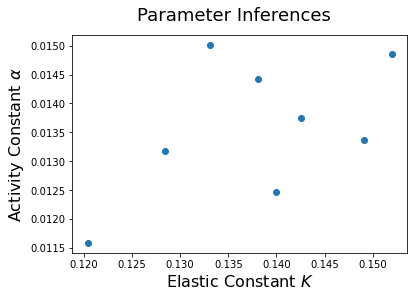

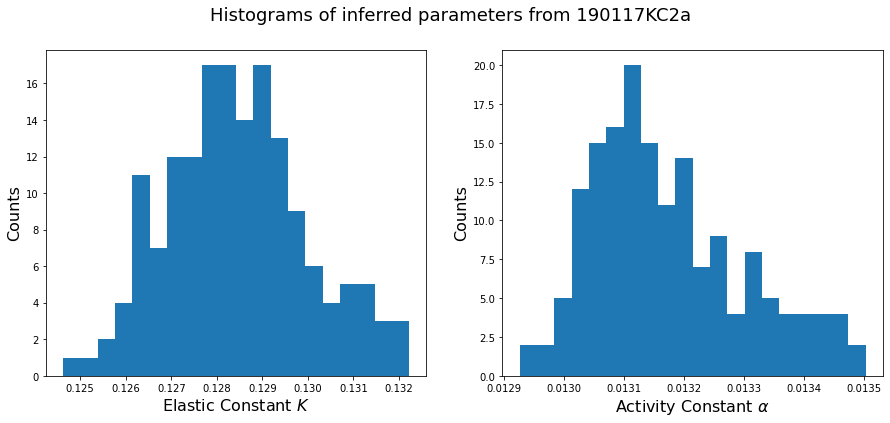

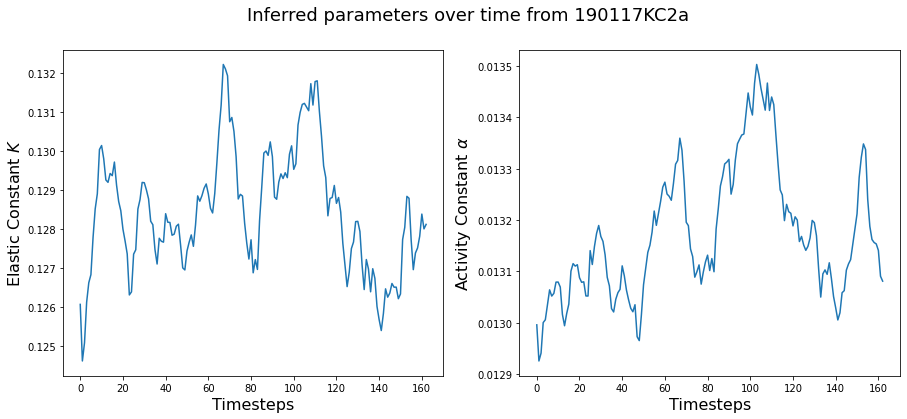

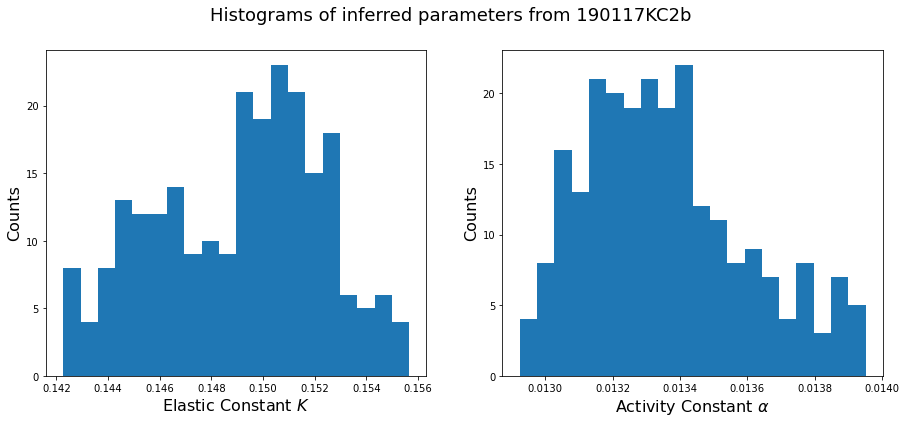

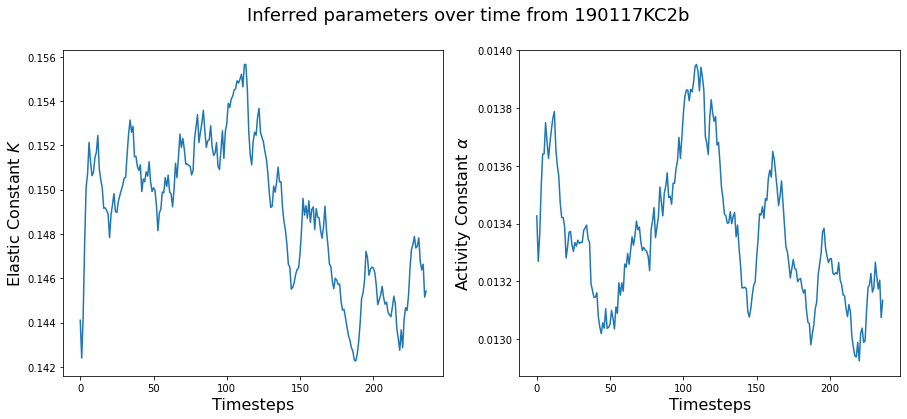

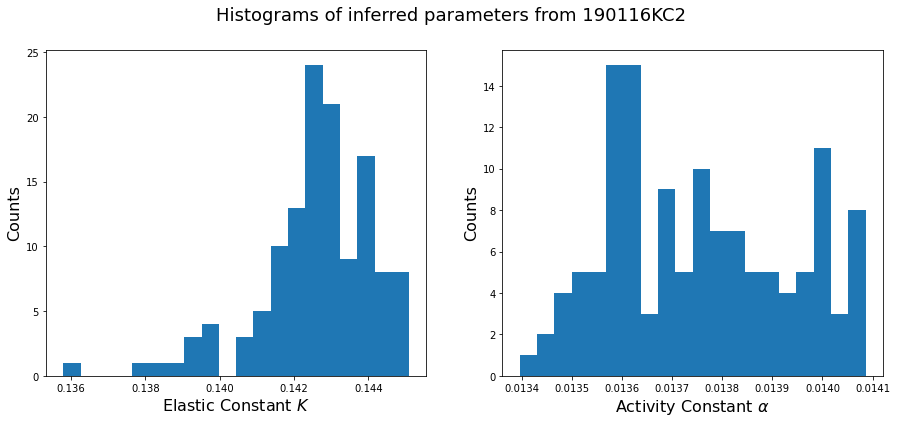

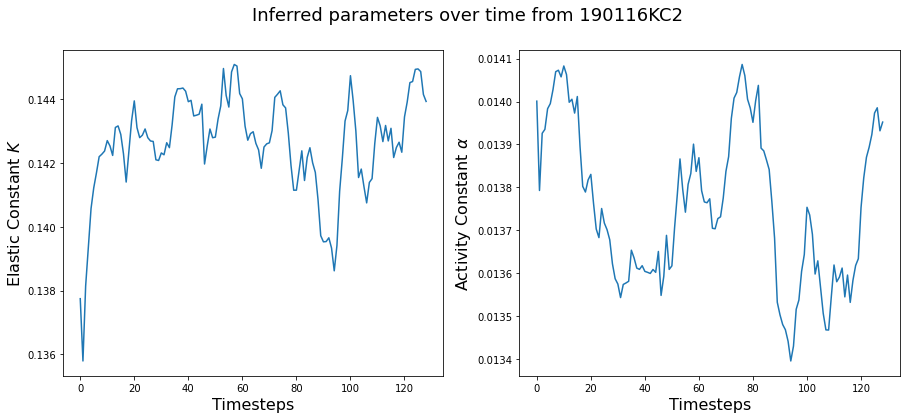

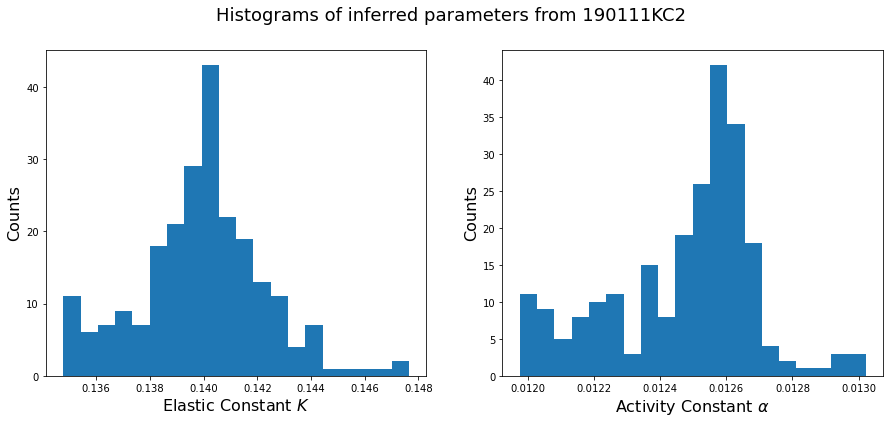

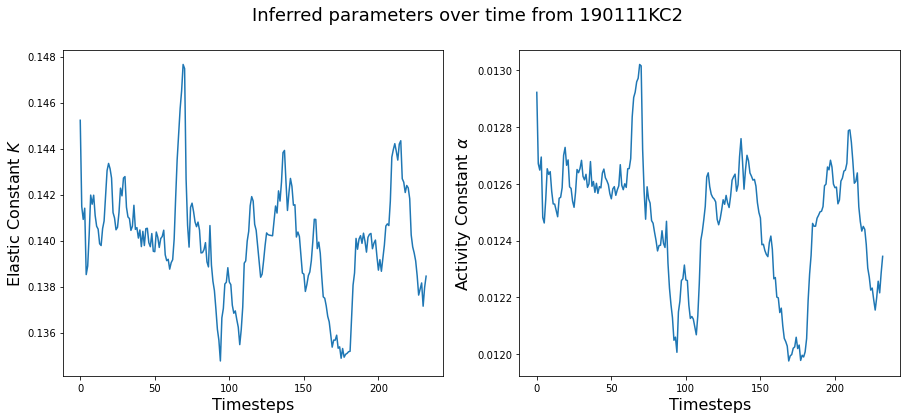

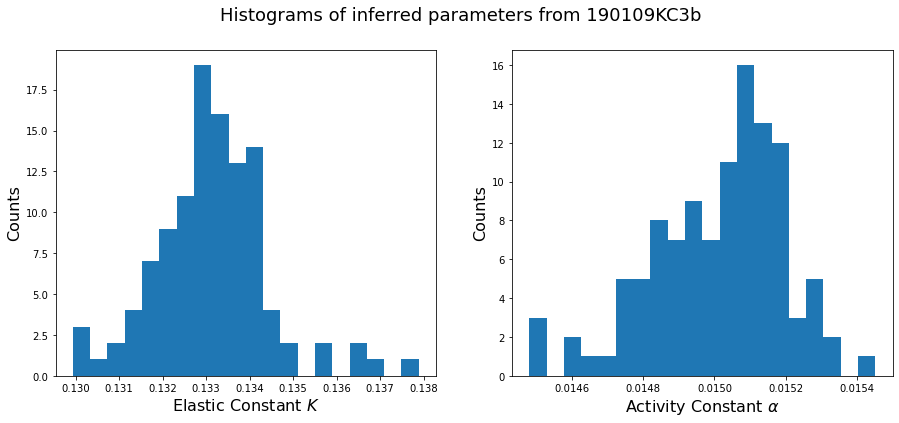

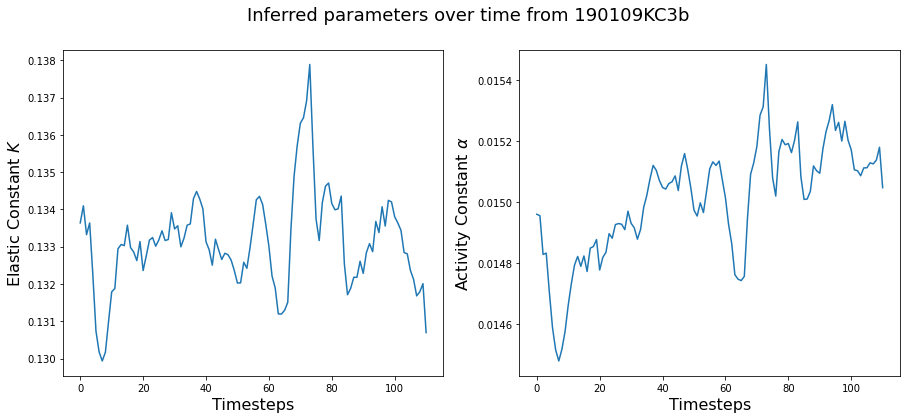

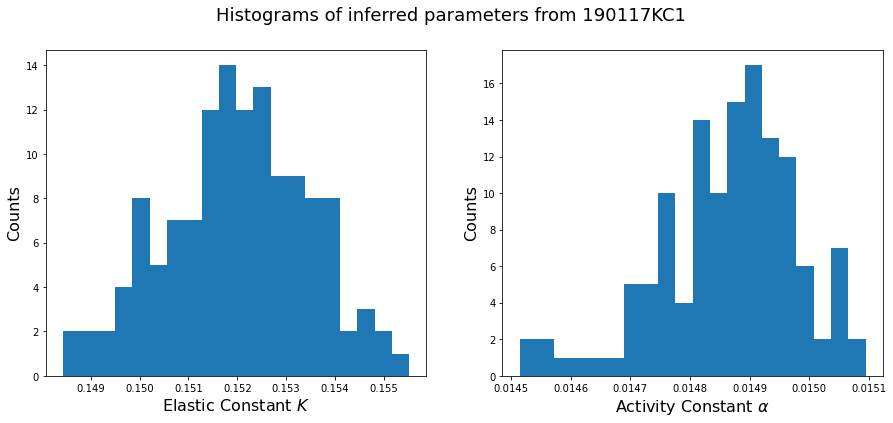

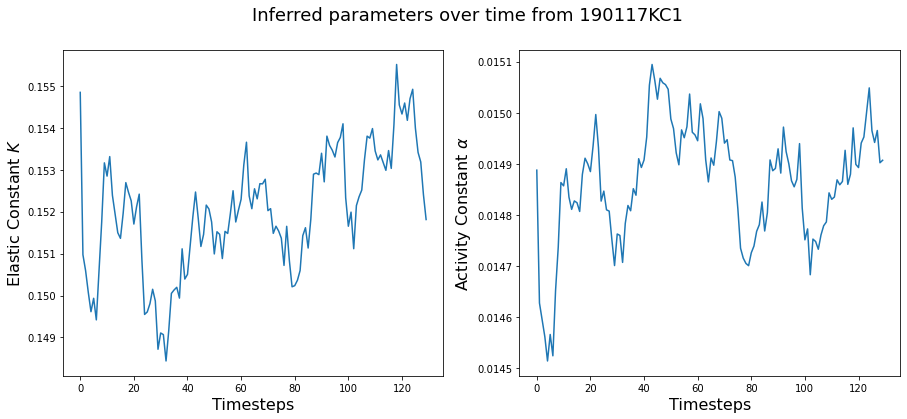

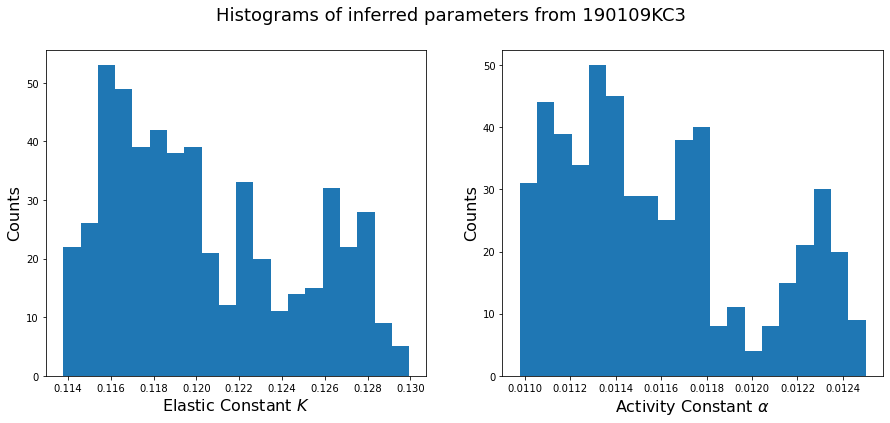

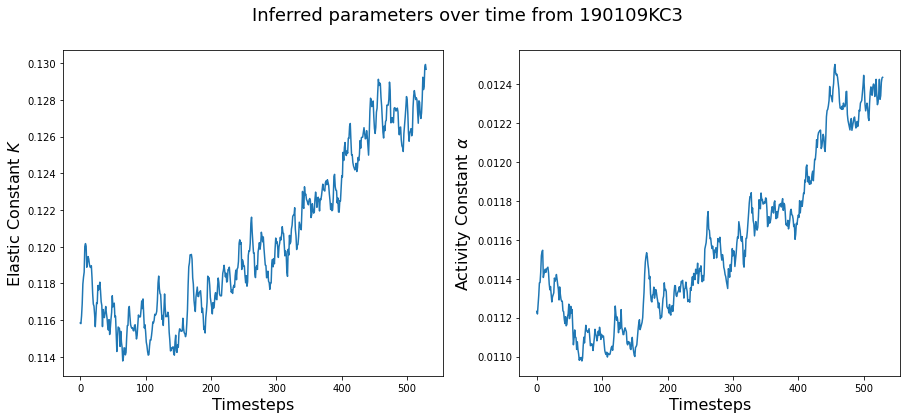

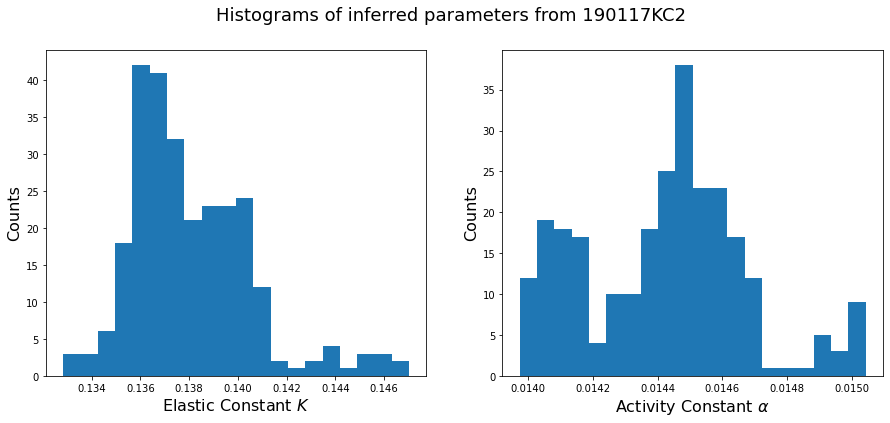

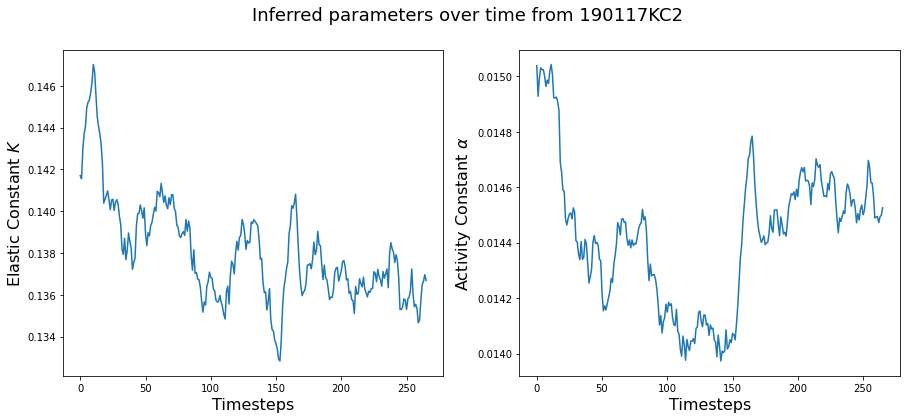

In [171]:
dir = '../../../data/inferences/ConvNextParameterEstimator_KZ_v3'
files = [file for file in Path(dir).iterdir() if file.is_file() and file.suffix == ".csv" and not file.name.startswith("._")]

output_dir = os.path.expanduser('~/Downloads')

plot_all(files, output_dir)